# 03 — CNN entrenada desde cero

Cinco experimentos progresivos sobre `src.models.ChemCNN`:

| # | Configuración | Hipótesis |
|---|---|---|
| 1 | Baseline: 2 bloques, LR=1e-3, sin dropout, sin augm. | Sub-fit + overfit fácil |
| 2 | Profundidad: 4 bloques | Más capacidad → menos sesgo |
| 3 | + Dropout 0.4 | Regulariza |
| 4 | + Augmentación | Cierra el gap train-val |
| 5 | + LR tuning + CosineAnnealing + early stopping | Mejor configuración final |

Cada experimento muestra curvas, gap de overfitting y métricas. Al final: tabla resumen + matriz de confusión del mejor.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch, numpy as np, random
torch.manual_seed(42); np.random.seed(42); random.seed(42)
torch.backends.cudnn.benchmark = True  # acelera convoluciones de tamaño fijo

METADATA_PATH = ROOT / 'data' / 'metadata.csv'
MODELS_DIR    = ROOT / 'saved_models'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

from src import (ChemCNN, get_dataloaders, train_model,
                 plot_training_curves, full_evaluation_report,
                 plot_confusion_matrix, plot_per_class_f1,
                 find_top_confused_pairs,
                 TRAIN_TRANSFORM, VAL_TRANSFORM)
import albumentations as A
from albumentations.pytorch import ToTensorV2

NO_AUG_TRANSFORM = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.0 GB


In [2]:
EPOCHS = 15
BATCH = 128 if DEVICE == 'cuda' else 32
NUM_WORKERS = 4 if DEVICE == 'cuda' else 0

train_loader, val_loader, test_loader, class_names, class_to_idx = get_dataloaders(
    metadata_path=str(METADATA_PATH), batch_size=BATCH, num_workers=NUM_WORKERS, root_dir=ROOT,
)
NUM_CLASSES = len(class_names)
print(f'NUM_CLASSES = {NUM_CLASSES}')
print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

NUM_CLASSES = 196
Train batches: 322  Val: 69  Test: 69


[Exp1-baseline] Epoch   1/15 | train_loss=4.6341 train_acc=0.0333 | val_loss=3.8291 val_acc=0.0771 | 205.7s


[Exp1-baseline] Epoch   2/15 | train_loss=3.4356 train_acc=0.1208 | val_loss=3.3785 val_acc=0.1235 | 65.9s


[Exp1-baseline] Epoch   3/15 | train_loss=2.9705 train_acc=0.1906 | val_loss=3.4594 val_acc=0.1193 | 71.6s


[Exp1-baseline] Epoch   4/15 | train_loss=2.6958 train_acc=0.2334 | val_loss=3.5724 val_acc=0.1137 | 74.9s


[Exp1-baseline] Epoch   5/15 | train_loss=2.5304 train_acc=0.2671 | val_loss=3.3595 val_acc=0.1488 | 78.7s


...

[Exp1-baseline] Epoch  11/15 | train_loss=1.9600 train_acc=0.3947 | val_loss=1.9307 val_acc=0.3998 | 82.0s


[Exp1-baseline] Epoch  12/15 | train_loss=1.9136 train_acc=0.4109 | val_loss=1.9445 val_acc=0.4033 | 82.3s


[Exp1-baseline] Epoch  13/15 | train_loss=1.9015 train_acc=0.4163 | val_loss=1.8301 val_acc=0.4446 | 83.7s


[Exp1-baseline] Epoch  14/15 | train_loss=1.8833 train_acc=0.4281 | val_loss=1.8113 val_acc=0.4700 | 83.1s


[Exp1-baseline] Epoch  15/15 | train_loss=1.8692 train_acc=0.4353 | val_loss=1.8006 val_acc=0.4782 | 84.0s


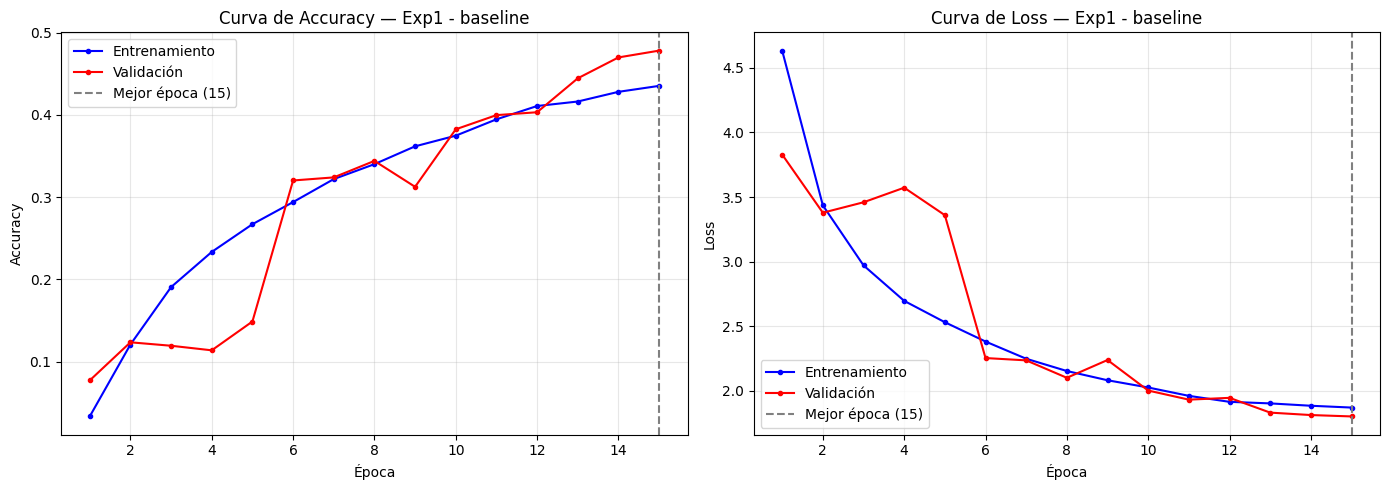

In [3]:
# Exp 1: baseline — 2 bloques, sin dropout, sin augmentation
train_loader_noaug, _, _, _, _ = get_dataloaders(
    metadata_path=str(METADATA_PATH), batch_size=BATCH, num_workers=NUM_WORKERS, root_dir=ROOT,
    train_transform=NO_AUG_TRANSFORM, use_weighted_sampler=False,
)
model = ChemCNN(num_classes=NUM_CLASSES, n_blocks=2, dropout=0.0)
h1 = train_model(model, train_loader_noaug, val_loader, epochs=EPOCHS, device=DEVICE,
                 patience=20, experiment_name='Exp1-baseline')
plot_training_curves(h1, 'Exp1 - baseline')

[Exp2-deeper] Epoch   1/15 | train_loss=3.4693 train_acc=0.1434 | val_loss=2.5029 val_acc=0.2178 | 96.2s


[Exp2-deeper] Epoch   2/15 | train_loss=1.7152 train_acc=0.4391 | val_loss=2.1575 val_acc=0.2907 | 96.5s


[Exp2-deeper] Epoch   3/15 | train_loss=1.1230 train_acc=0.6102 | val_loss=1.8670 val_acc=0.3786 | 95.9s


[Exp2-deeper] Epoch   4/15 | train_loss=0.7852 train_acc=0.7259 | val_loss=1.9111 val_acc=0.4283 | 97.1s


[Exp2-deeper] Epoch   5/15 | train_loss=0.5421 train_acc=0.8196 | val_loss=0.6018 val_acc=0.7851 | 95.3s


...

[Exp2-deeper] Epoch  11/15 | train_loss=0.1112 train_acc=0.9703 | val_loss=0.2751 val_acc=0.8971 | 94.2s


[Exp2-deeper] Epoch  12/15 | train_loss=0.0970 train_acc=0.9760 | val_loss=0.1721 val_acc=0.9405 | 95.5s


[Exp2-deeper] Epoch  13/15 | train_loss=0.0873 train_acc=0.9789 | val_loss=0.0862 val_acc=0.9753 | 93.2s


[Exp2-deeper] Epoch  14/15 | train_loss=0.0789 train_acc=0.9823 | val_loss=0.0859 val_acc=0.9757 | 95.1s


[Exp2-deeper] Epoch  15/15 | train_loss=0.0746 train_acc=0.9841 | val_loss=0.0754 val_acc=0.9819 | 100.3s


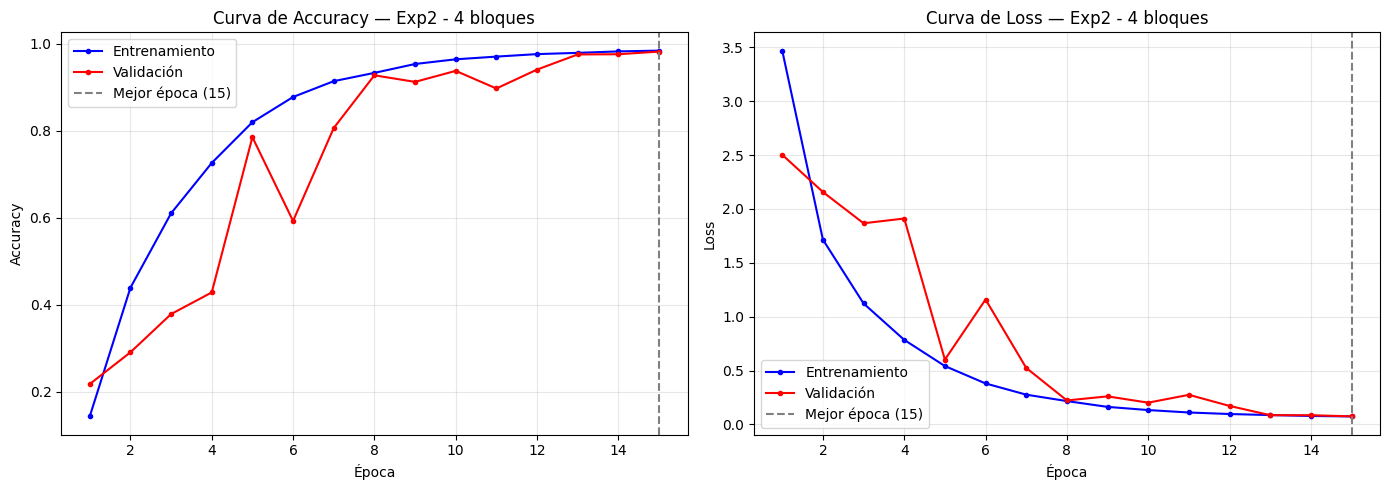

In [4]:
model = ChemCNN(num_classes=NUM_CLASSES, n_blocks=4, dropout=0.0)
h2 = train_model(model, train_loader_noaug, val_loader, epochs=EPOCHS, device=DEVICE,
                 patience=20, experiment_name='Exp2-deeper')
plot_training_curves(h2, 'Exp2 - 4 bloques')

[Exp3-dropout] Epoch   1/15 | train_loss=3.7882 train_acc=0.0932 | val_loss=3.1545 val_acc=0.0977 | 108.7s


[Exp3-dropout] Epoch   2/15 | train_loss=2.0844 train_acc=0.3347 | val_loss=2.6203 val_acc=0.2109 | 95.5s


[Exp3-dropout] Epoch   3/15 | train_loss=1.4650 train_acc=0.4901 | val_loss=1.4269 val_acc=0.5180 | 94.5s


[Exp3-dropout] Epoch   4/15 | train_loss=1.1418 train_acc=0.5898 | val_loss=0.8728 val_acc=0.6932 | 95.9s


[Exp3-dropout] Epoch   5/15 | train_loss=0.8684 train_acc=0.6883 | val_loss=0.7465 val_acc=0.7158 | 96.8s


...

[Exp3-dropout] Epoch  11/15 | train_loss=0.2818 train_acc=0.9079 | val_loss=0.2607 val_acc=0.9110 | 97.7s


[Exp3-dropout] Epoch  12/15 | train_loss=0.2572 train_acc=0.9168 | val_loss=0.1563 val_acc=0.9483 | 96.6s


[Exp3-dropout] Epoch  13/15 | train_loss=0.2377 train_acc=0.9251 | val_loss=0.1263 val_acc=0.9679 | 98.1s


[Exp3-dropout] Epoch  14/15 | train_loss=0.2252 train_acc=0.9299 | val_loss=0.1184 val_acc=0.9701 | 96.7s


[Exp3-dropout] Epoch  15/15 | train_loss=0.2163 train_acc=0.9328 | val_loss=0.1139 val_acc=0.9721 | 98.9s


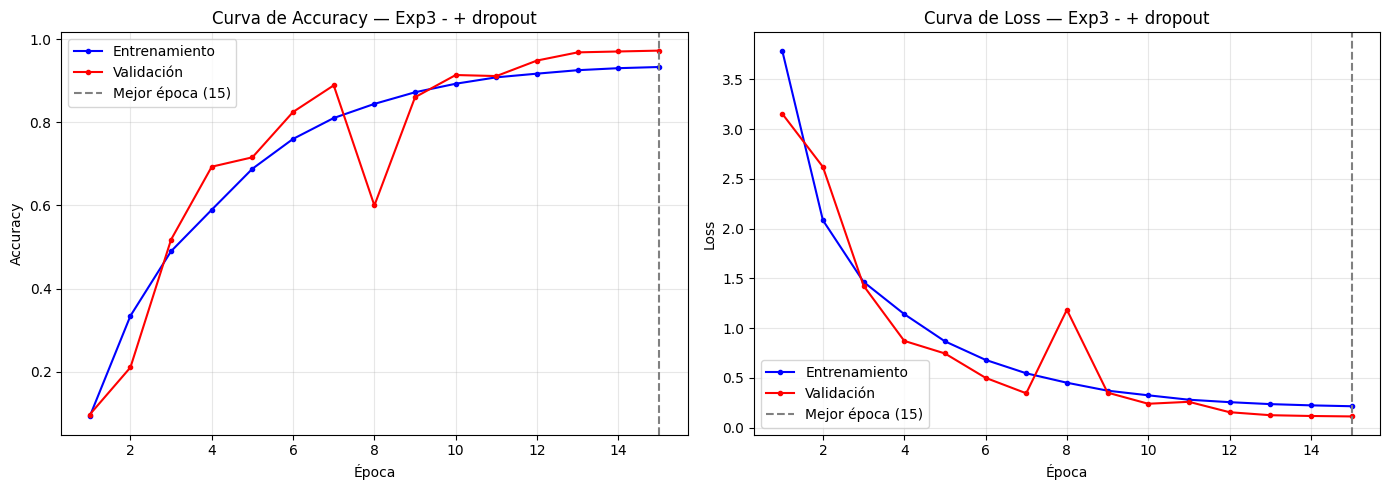

In [5]:
model = ChemCNN(num_classes=NUM_CLASSES, n_blocks=4, dropout=0.4)
h3 = train_model(model, train_loader_noaug, val_loader, epochs=EPOCHS, device=DEVICE,
                 patience=20, experiment_name='Exp3-dropout')
plot_training_curves(h3, 'Exp3 - + dropout')

[Exp4-aug] Epoch   1/15 | train_loss=4.3062 train_acc=0.0419 | val_loss=3.2551 val_acc=0.1056 | 153.4s


[Exp4-aug] Epoch   2/15 | train_loss=2.7494 train_acc=0.1998 | val_loss=2.9302 val_acc=0.1471 | 134.0s


[Exp4-aug] Epoch   3/15 | train_loss=2.0268 train_acc=0.3391 | val_loss=1.9137 val_acc=0.3438 | 138.2s


[Exp4-aug] Epoch   4/15 | train_loss=1.6865 train_acc=0.4286 | val_loss=1.3338 val_acc=0.5161 | 139.4s


[Exp4-aug] Epoch   5/15 | train_loss=1.4356 train_acc=0.5000 | val_loss=1.2763 val_acc=0.5173 | 138.8s


...

[Exp4-aug] Epoch  11/15 | train_loss=0.7433 train_acc=0.7482 | val_loss=0.5051 val_acc=0.8127 | 150.1s


[Exp4-aug] Epoch  12/15 | train_loss=0.7117 train_acc=0.7612 | val_loss=0.3251 val_acc=0.9363 | 146.7s


[Exp4-aug] Epoch  13/15 | train_loss=0.6822 train_acc=0.7720 | val_loss=0.2827 val_acc=0.9426 | 144.4s


[Exp4-aug] Epoch  14/15 | train_loss=0.6399 train_acc=0.7898 | val_loss=0.2603 val_acc=0.9578 | 136.0s


[Exp4-aug] Epoch  15/15 | train_loss=0.6382 train_acc=0.7922 | val_loss=0.2600 val_acc=0.9598 | 137.0s


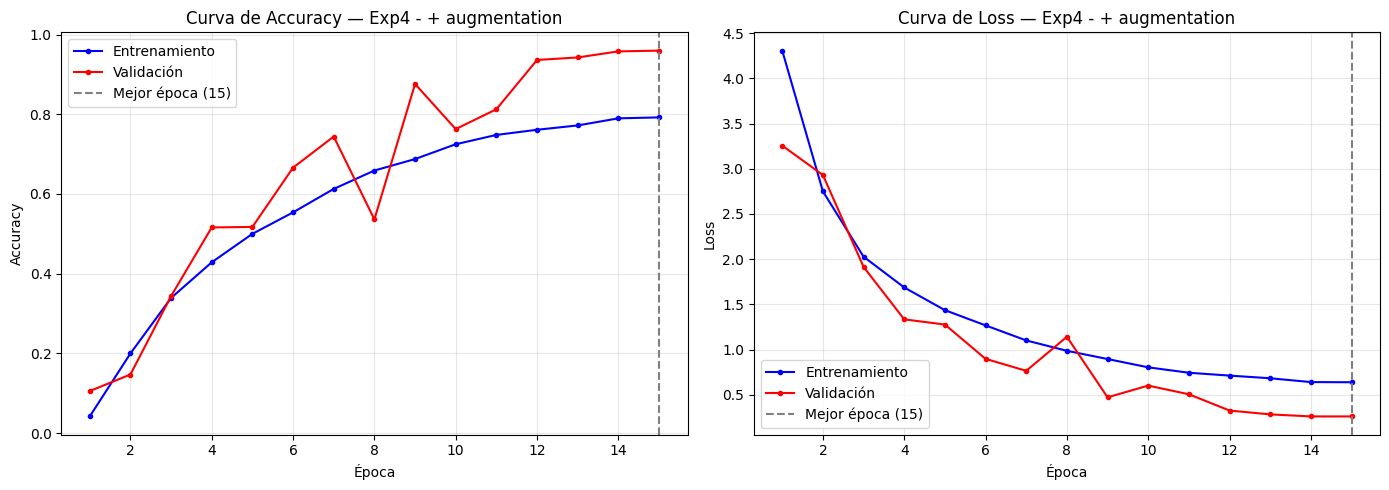

In [6]:
model = ChemCNN(num_classes=NUM_CLASSES, n_blocks=4, dropout=0.4)
h4 = train_model(model, train_loader, val_loader, epochs=EPOCHS, device=DEVICE,
                 patience=20, experiment_name='Exp4-aug')
plot_training_curves(h4, 'Exp4 - + augmentation')

[Exp5-tuned] Epoch   1/15 | train_loss=5.0691 train_acc=0.0172 | val_loss=4.5043 val_acc=0.0346 | 135.0s


[Exp5-tuned] Epoch   2/15 | train_loss=4.1850 train_acc=0.0585 | val_loss=3.6489 val_acc=0.1400 | 137.6s


[Exp5-tuned] Epoch   3/15 | train_loss=3.6169 train_acc=0.1128 | val_loss=3.1190 val_acc=0.2289 | 136.7s


[Exp5-tuned] Epoch   4/15 | train_loss=3.2234 train_acc=0.1658 | val_loss=2.8461 val_acc=0.2359 | 137.4s


[Exp5-tuned] Epoch   5/15 | train_loss=2.9083 train_acc=0.2137 | val_loss=2.5158 val_acc=0.3266 | 136.8s


...

[Exp5-tuned] Epoch  11/15 | train_loss=2.1009 train_acc=0.3622 | val_loss=1.6312 val_acc=0.5867 | 136.5s


[Exp5-tuned] Epoch  12/15 | train_loss=2.0588 train_acc=0.3729 | val_loss=1.5827 val_acc=0.6253 | 145.0s


[Exp5-tuned] Epoch  13/15 | train_loss=2.0274 train_acc=0.3784 | val_loss=1.5555 val_acc=0.6439 | 143.8s


[Exp5-tuned] Epoch  14/15 | train_loss=2.0145 train_acc=0.3778 | val_loss=1.5423 val_acc=0.6550 | 134.7s


[Exp5-tuned] Epoch  15/15 | train_loss=2.0141 train_acc=0.3851 | val_loss=1.5343 val_acc=0.6552 | 136.6s


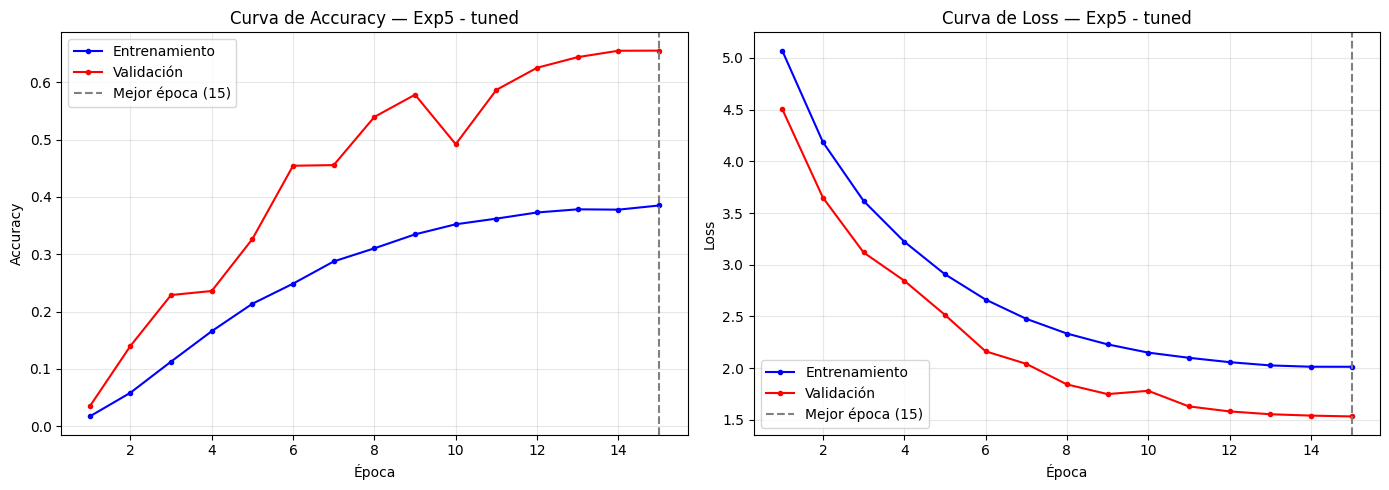

In [7]:
model = ChemCNN(num_classes=NUM_CLASSES, n_blocks=4, dropout=0.4)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
save_path = str(MODELS_DIR / 'chemcnn_best.pt')
h5 = train_model(model, train_loader, val_loader, epochs=EPOCHS, device=DEVICE,
                 optimizer=opt, scheduler=sched, patience=8,
                 save_path=save_path, experiment_name='Exp5-tuned')
plot_training_curves(h5, 'Exp5 - tuned')

,exp,best_val_acc,final_train_acc,gap (train - val),best_epoch
0,Exp1,0.478231,0.435350,-0.042881,15
1,Exp2,0.981859,0.984062,0.002203,15
2,Exp3,0.972109,0.932750,-0.039359,15
3,Exp4,0.959751,0.792225,-0.167525,15
4,Exp5,0.655215,0.385083,-0.270133,15



Test accuracy (Exp5): 0.655
Macro F1:            0.624


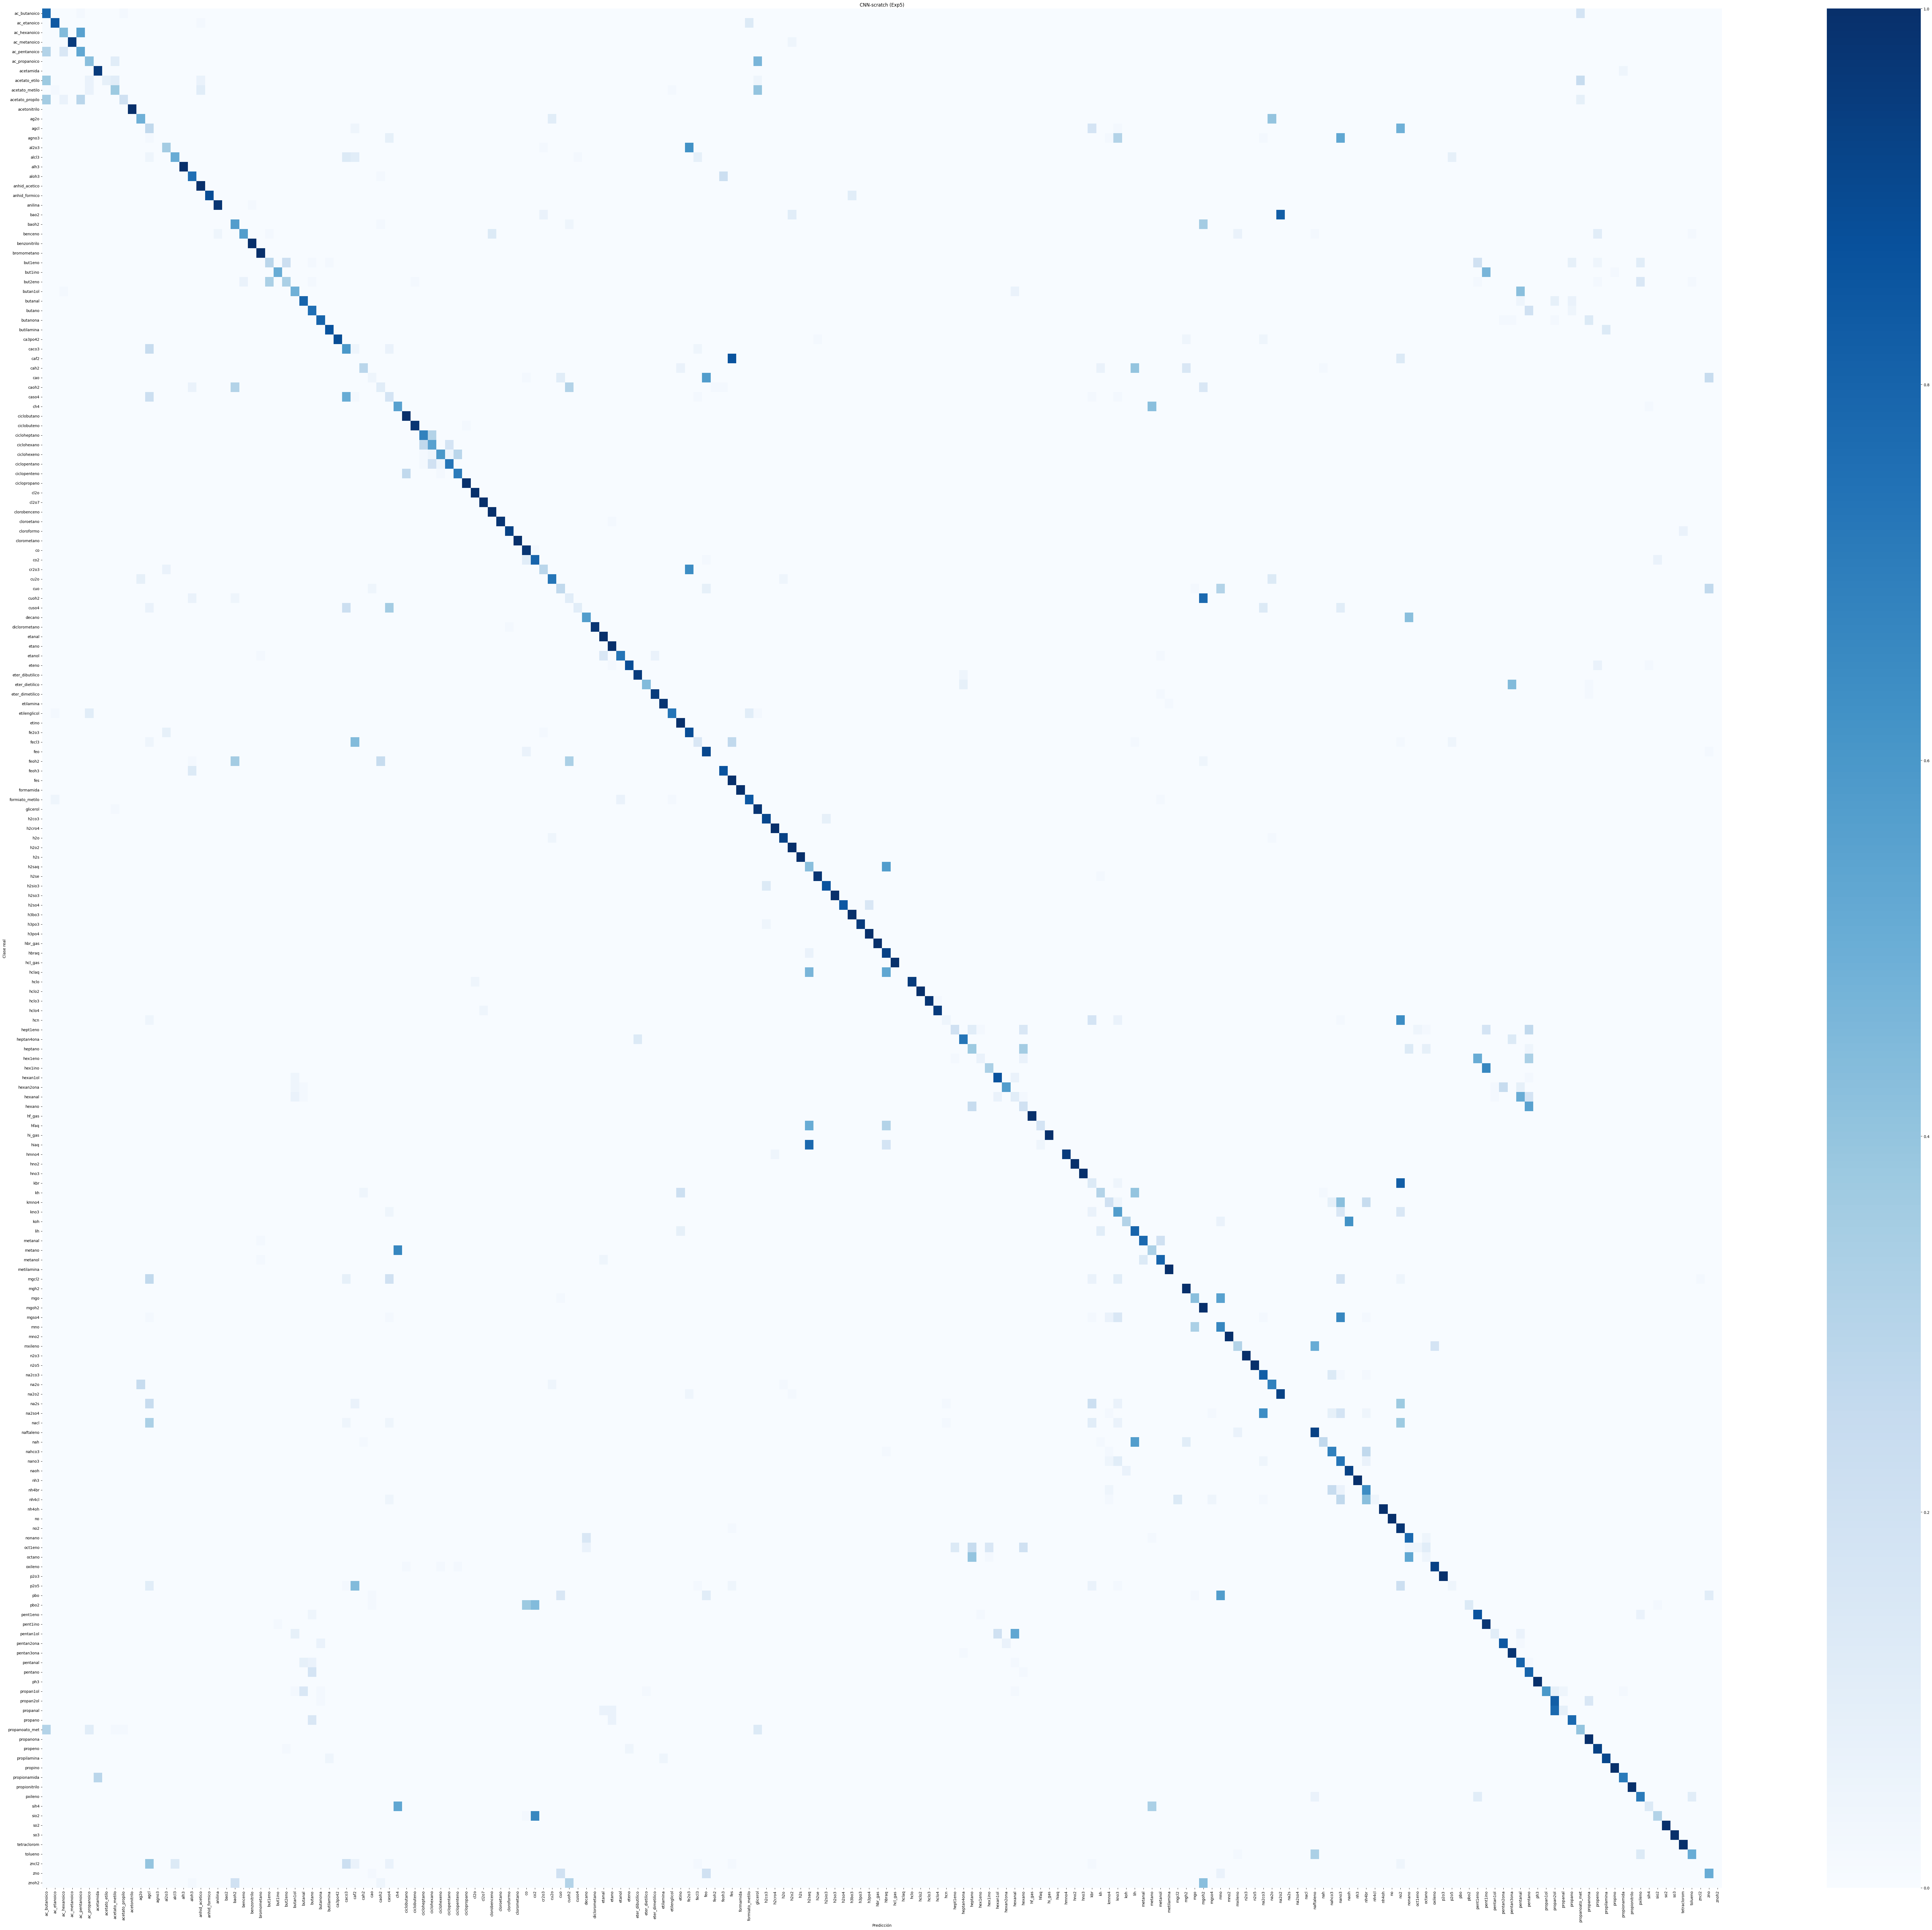

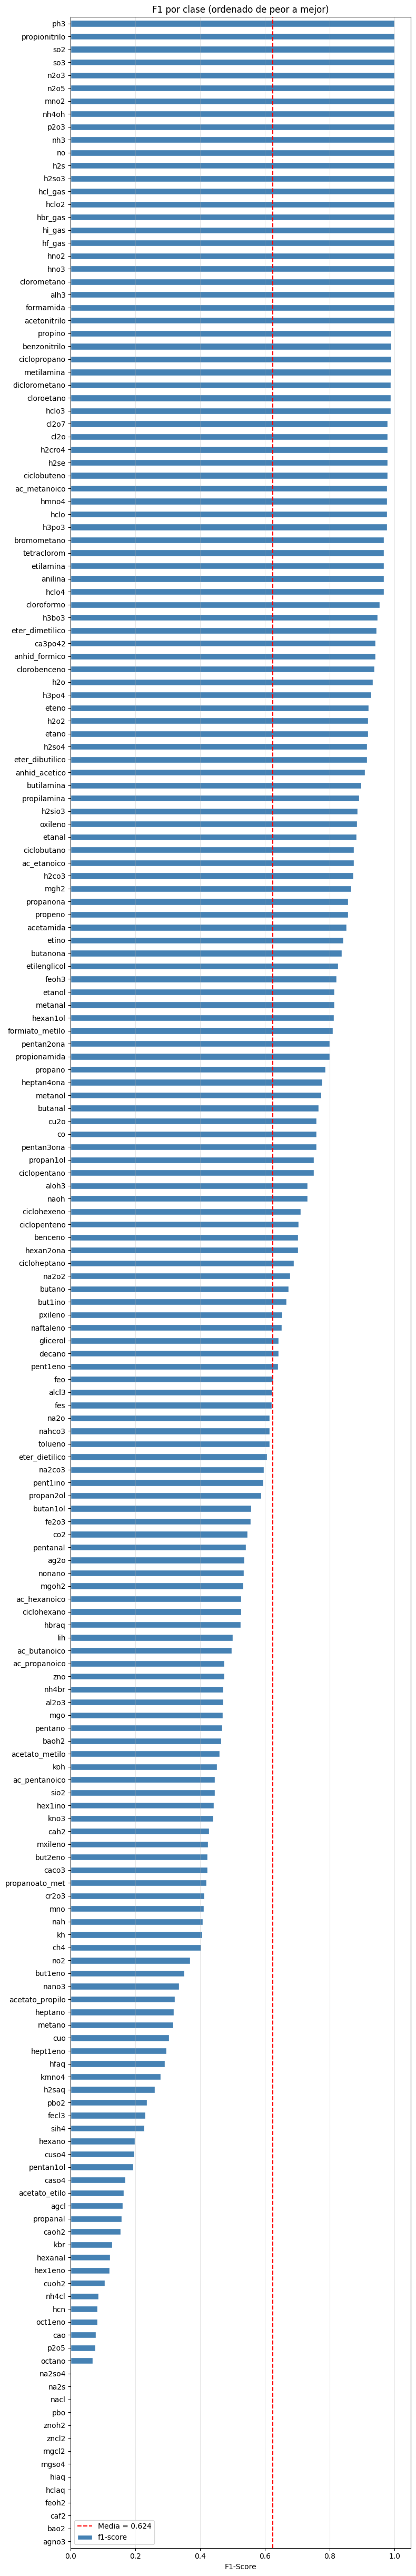


Top-5 pares más confundidos:


,true,predicted,count
0,caf2,fes,39
1,bao2,na2o2,37
2,kbr,no2,37
3,cuoh2,mgoh2,35
4,propanal,propan2ol,35


In [8]:
import pandas as pd
rows = []
for name, h in [('Exp1', h1), ('Exp2', h2), ('Exp3', h3), ('Exp4', h4), ('Exp5', h5)]:
    rows.append({
        'exp': name,
        'best_val_acc': max(h['val_acc']),
        'final_train_acc': h['train_acc'][-1],
        'gap (train - val)': h['train_acc'][-1] - max(h['val_acc']),
        'best_epoch': h['best_epoch'],
    })
summary = pd.DataFrame(rows)
display(summary)

# Evaluación final del Exp5 en test
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
rep = full_evaluation_report(model, test_loader, class_names, device=DEVICE)
print(f"\nTest accuracy (Exp5): {rep['accuracy']:.3f}")
print(f"Macro F1:            {rep['macro_f1']:.3f}")
plot_confusion_matrix(rep['confusion_matrix'], class_names, title='CNN-scratch (Exp5)')
plot_per_class_f1(rep['report_df'])
print('\nTop-5 pares más confundidos:')
display(find_top_confused_pairs(rep['confusion_matrix'], class_names, top_k=5))

## Conclusiones

- Cada modificación (profundidad, dropout, aumentación, scheduler) reduce el gap train-val o eleva la val_acc en un grado distinto.
- La aumentación es clave para evitar el overfitting típico cuando todas las imágenes de una clase derivan de la misma fuente.
- Aun con el Exp5, la CNN desde cero queda por debajo de lo que puede dar una red preentrenada. Pasamos a transfer learning en el notebook 04.